In [1]:
%pip install nltk

In [2]:
import numpy as np
import pandas as pd
import nltk
import re

nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
df = pd.read_csv(
    'Restaurant_Reviews.tsv',
    delimiter='\t',
    quoting=3
)

df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [5]:
df.shape

(1000, 2)

In [7]:
corpus = []

for i in range(0, 1000):

    review = re.sub(
        pattern='[^a-zA-Z]',
        repl=' ',
        string=df['Review'][i]
    )

    review = review.lower()
    review_words = review.split()
    review_words = [
        word for word in review_words
        if not word in set(stopwords.words('english'))
    ]


    ps = PorterStemmer()
    review = [ps.stem(word) for word in review_words]
    review = ' '.join(review)
    corpus.append(review)

print(corpus[0:10])

['wow love place', 'crust good', 'tasti textur nasti', 'stop late may bank holiday rick steve recommend love', 'select menu great price', 'get angri want damn pho', 'honeslti tast fresh', 'potato like rubber could tell made ahead time kept warmer', 'fri great', 'great touch']


In [8]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=1500)

X = cv.fit_transform(corpus).toarray()

y = df.iloc[:, 1].values

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.20, random_state = 0)
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=35)
model.fit(X_train, y_train)
RandomForestClassifier(n_estimators=35)
model.score(X_test, y_test)


0.69

In [21]:
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

score1 = accuracy_score(y_test, y_pred)
score2 = precision_score(y_test, y_pred)
score3 = recall_score(y_test, y_pred)

print("---- Scores ---- ")

print("Accuracy score is: {}%".format(
    round(score1 * 100, 2)
))

print("Precision score is: {}".format(
    round(score2, 2)
))

print("Recall score is: {}".format(
    round(score3, 2)
))

---- Scores ---- 
Accuracy score is: 69.0%
Precision score is: 0.81
Recall score is: 0.52


Text(33.222222222222214, 0.5, 'Actual values')

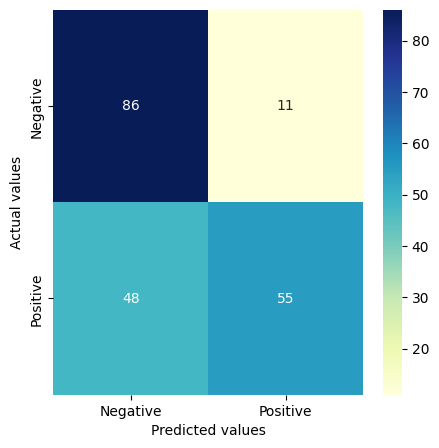

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.figure(figsize=(5, 5))

sns.heatmap(
    cm,
    annot=True,
    cmap="YlGnBu",
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel('Predicted values')
plt.ylabel('Actual values')

In [14]:
best_accuracy = 0.0
n_estimators = 5

for i in np.arange(1, 30, 2):

    temp_classifier = RandomForestClassifier(
        n_estimators=i
    )

    temp_classifier.fit(X_train, y_train)

    temp_y_pred = temp_classifier.predict(X_test)

    score = accuracy_score(y_test, temp_y_pred)

    print(
        "Accuracy score for n_estimators={} is: {}%"
        .format(
            round(i, 1),
            round(score * 100, 2)
        )
    )

    if score > best_accuracy:

        best_accuracy = score
        n_estimators_val = i

        print(' ')

print(
    'The best accuracy is {}% with n_estimators value as {}'
    .format(
        round(best_accuracy * 100, 2),
        round(n_estimators_val, 1)
    )
)

Accuracy score for n_estimators=1 is: 68.5%
 
Accuracy score for n_estimators=3 is: 72.0%
 
Accuracy score for n_estimators=5 is: 72.0%
Accuracy score for n_estimators=7 is: 70.5%
Accuracy score for n_estimators=9 is: 66.0%
Accuracy score for n_estimators=11 is: 68.5%
Accuracy score for n_estimators=13 is: 71.5%
Accuracy score for n_estimators=15 is: 72.0%
Accuracy score for n_estimators=17 is: 69.0%
Accuracy score for n_estimators=19 is: 69.5%
Accuracy score for n_estimators=21 is: 72.0%
Accuracy score for n_estimators=23 is: 70.0%
Accuracy score for n_estimators=25 is: 70.5%
Accuracy score for n_estimators=27 is: 70.0%
Accuracy score for n_estimators=29 is: 71.0%
The best accuracy is 72.0% with n_estimators value as 3


In [22]:
model = RandomForestClassifier(
    n_estimators=n_estimators_val
)

model.fit(X_train, y_train)
RandomForestClassifier(n_estimators=19)

RandomForestClassifier(n_estimators=19)

In [16]:
def predict_sentiment(sample_review):

    sample_review = re.sub(
        pattern='[^a-zA-Z]',
        repl=' ',
        string=sample_review
    )

    sample_review = sample_review.lower()

    sample_review_words = sample_review.split()

    sample_review_words = [
        word for word in sample_review_words
        if not word in set(stopwords.words('english'))
    ]

    ps = PorterStemmer()

    final_review = [
        ps.stem(word)
        for word in sample_review_words
    ]

    final_review = ' '.join(final_review)

    temp = cv.transform([final_review]).toarray()

    return model.predict(temp)

In [17]:
sample_review = 'The food is really good here.'

print("Review:", sample_review)

if predict_sentiment(sample_review):
    print('This is a POSITIVE review.')
else:
    print('This is a NEGATIVE review!')

Review: The food is really good here.
This is a NEGATIVE review!


In [18]:
sample_review = 'Food was pretty bad and the service was very slow.'

print("Review:", sample_review)

if predict_sentiment(sample_review):
    print('This is a POSITIVE review.')
else:
    print('This is a NEGATIVE review!')

Review: Food was pretty bad and the service was very slow.
This is a NEGATIVE review!


In [19]:
sample_review = 'The food was absolutely wonderful and nicely presentation'

print("Review:", sample_review)

if predict_sentiment(sample_review):
    print('This is a POSITIVE review.')
else:
    print('This is a NEGATIVE review!')

Review: The food was absolutely wonderful and nicely presentation
This is a NEGATIVE review!
